In [3]:
# imports 
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Setup Device agnostic code

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count", torch.cuda.device_count())

CUDA available: True
CUDA version: 11.8
GPU count 1


In [4]:
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "food-101"

print(f"The the datapath: {data_path}")
print(f"The image path: {image_path}")

The the datapath: data
The image path: data\food-101


### Visualize the image

In [6]:
image_path

WindowsPath('data/food-101')

data\food-101\images\croque_madame\670688.jpg
croque_madame
Random image path: data\food-101\images\croque_madame\670688.jpg
Image class: croque_madame
Image height: 512
Image width: 512


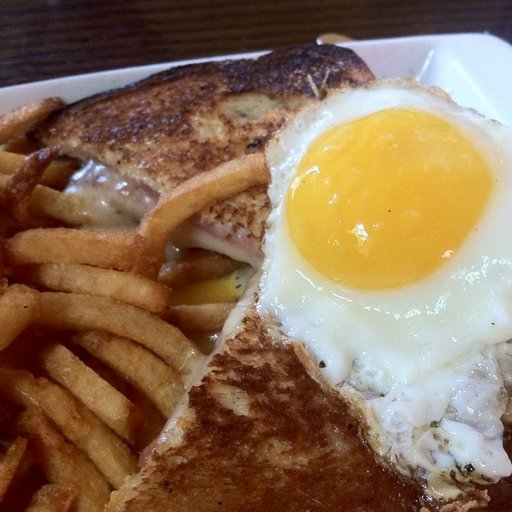

In [9]:
import random
from PIL import Image

#random.seed(42)

#1. Get all the path
image_path_list = list(image_path.glob("*/*/*.jpg"))
#print(f"Image path list : {image_path_list}")

#2. Pick a random image path 
random_image_path = random.choice(image_path_list)
print(random_image_path)

#3. get the image class (the image class is the name of the directory wheree the image is stored)
image_class  = random_image_path.parent.stem
print(image_class)

#4. Open imamge
img = Image.open(random_image_path)

#5. Print metadata of the images
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
img

### Tranforming the data

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Ploting the transformed images

In [12]:
import matplotlib.pyplot as plt

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..2.3585434].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.5005665].


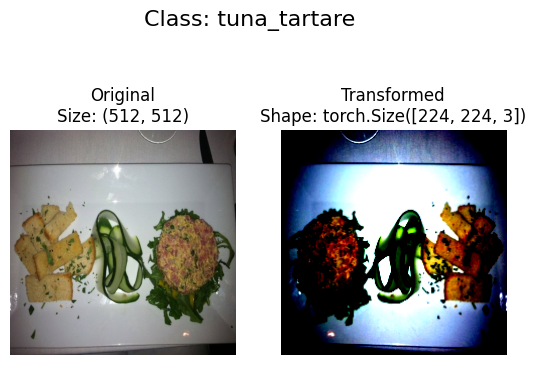

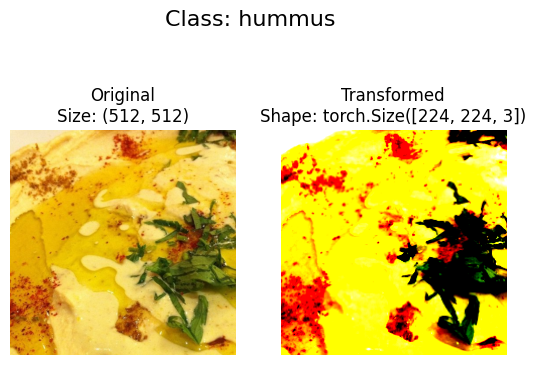

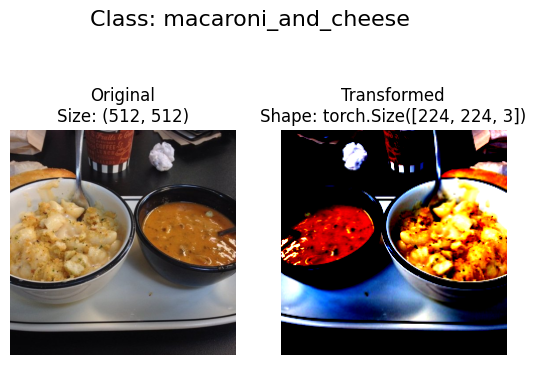

In [13]:
def plot_tranformed_images(image_paths:list,transform,n=3,seed=None):
    """ selects random images from a path of images and loads/transforms
        them then plots the original vs transformed version
    """

    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax= plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # transform and plot target image
            transformed_image = transform(f).permute(1,2,0) #Note we will need to change shape (C,H,W)->(H,W,C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}",fontsize = 16)

plot_tranformed_images(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None
                       )

### Load the dataset



In [15]:
train_dataset = datasets.Food101(
    root="data",
    split="train",
    transform=train_transform,
    download=False
)

test_dataset = datasets.Food101(
    root="data",
    split="test",
    transform=test_transform,
    download=False
)

In [16]:
train_dataset , test_dataset

(Dataset Food101
     Number of datapoints: 75750
     Root location: data
     split=train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset Food101
     Number of datapoints: 25250
     Root location: data
     split=test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [17]:
#Get class names
class_names = train_dataset.classes
len(class_names)

101

In [18]:
# class to idx
class_dict = train_dataset.class_to_idx
class_dict

{'apple_pie': 0,
 'baby_back_ribs': 1,
 'baklava': 2,
 'beef_carpaccio': 3,
 'beef_tartare': 4,
 'beet_salad': 5,
 'beignets': 6,
 'bibimbap': 7,
 'bread_pudding': 8,
 'breakfast_burrito': 9,
 'bruschetta': 10,
 'caesar_salad': 11,
 'cannoli': 12,
 'caprese_salad': 13,
 'carrot_cake': 14,
 'ceviche': 15,
 'cheese_plate': 16,
 'cheesecake': 17,
 'chicken_curry': 18,
 'chicken_quesadilla': 19,
 'chicken_wings': 20,
 'chocolate_cake': 21,
 'chocolate_mousse': 22,
 'churros': 23,
 'clam_chowder': 24,
 'club_sandwich': 25,
 'crab_cakes': 26,
 'creme_brulee': 27,
 'croque_madame': 28,
 'cup_cakes': 29,
 'deviled_eggs': 30,
 'donuts': 31,
 'dumplings': 32,
 'edamame': 33,
 'eggs_benedict': 34,
 'escargots': 35,
 'falafel': 36,
 'filet_mignon': 37,
 'fish_and_chips': 38,
 'foie_gras': 39,
 'french_fries': 40,
 'french_onion_soup': 41,
 'french_toast': 42,
 'fried_calamari': 43,
 'fried_rice': 44,
 'frozen_yogurt': 45,
 'garlic_bread': 46,
 'gnocchi': 47,
 'greek_salad': 48,
 'grilled_cheese_sa

In [19]:
# Check the length o0f our datasets
len(train_dataset),len(test_dataset)

(75750, 25250)

### Dataloaders

In [27]:
BATCH_SIZE = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [28]:
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x11873f79610>,
 <torch.utils.data.dataloader.DataLoader at 0x11871c47290>)

In [29]:
len(train_loader)== len(train_dataset),len(test_loader)==len(test_dataset)

(False, False)

In [30]:
img,label = next(iter(train_loader))

# Batch size will now be 1, try changing the batch_size parameter above and see what happens
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 224, 224]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([32])


###  Create a function to display random images

1. Take in a Dataset and a number of other parameters such as classes (the names of our target classes), the number of images to display (n) and a random seed.
2. To prevent the display getting out of hand, we'll cap n at 10 images.
3. Set the random seed for reproducible plots (if seed is set).
4. Get a list of random sample indexes (we can use Python's random.sample() for this) to plot.
5. Setup a matplotlib plot.
6. Loop through the random sample indexes found in step 4 and plot them with matplotlib.
7. Make sure the sample images are of shape HWC (height, width, color channels) so we can plot them.

In [33]:
from typing import List

In [34]:
# 1.Create a function to take in a dataset
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str] = None,
                          n:int = 10,
                          display_shape: bool = True,
                          seed:int = None):
    # 2. adjust the display if the n is too high
    if n>10:
        n = 10
        display_shape = False   
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")

    #3. setup seed
    if seed:
        random.seed(seed)

    #4. get random sample indexes
    random_samples_idx = random.sample(range(len(dataset)),k=n)

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].


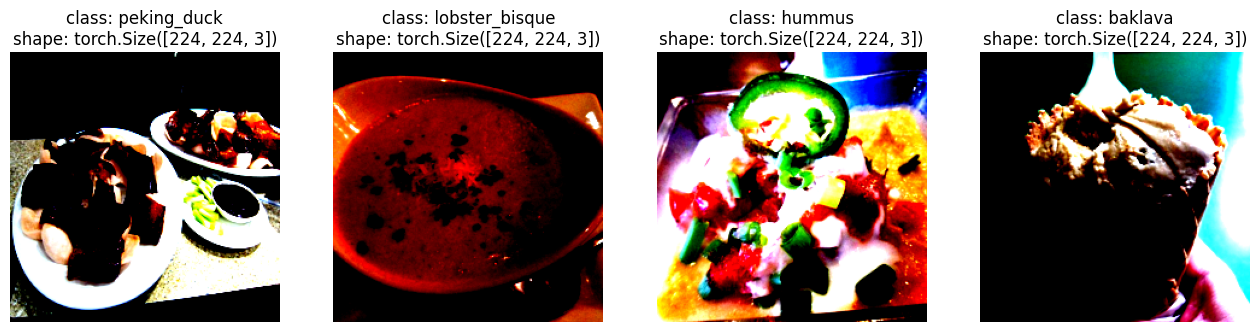

In [38]:
display_random_images(dataset=train_dataset,
                      classes=class_names,
                      n=4,
                      seed=None)

### Creating TinyVGG Model

In [39]:
class TinyVGG(nn.Module):
    def __init__(self,
                input_shape:int,
                hidden_units:int,
                output_shape:int):
        super().__init__()
        # Conv block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units*2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*2,
                      out_channels=hidden_units*2,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units*2,
                      out_channels=hidden_units*4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units*4,
                      out_channels=hidden_units*4,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        # Adaptive pooling (KEY PART)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*4 * 7 * 7,
                      out_features= 512),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=512,
                       out_features=output_shape)
        )
    def forward(self,x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x
        #return self.classifier(self.adaptive_pool(self.block3(self.block2(self.block1(x)))))
        


In [42]:
#Initilaize models
model_VGG = TinyVGG(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
).to(device)

model_VGG

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(7, 7))
  (classifier): Sequential(
    (0)

In [43]:
next(model_VGG.parameters()).device

device(type='cuda', index=0)

### Forward pass check

In [44]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_loader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_VGG.eval()
with torch.inference_mode():
    pred = model_VGG(img_single.to(device))
    
# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 224, 224])

Output logits:
tensor([[ 0.0215,  0.0194, -0.0009, -0.0109,  0.0252,  0.0310, -0.0131, -0.0196,
         -0.0307, -0.0292,  0.0423,  0.0418,  0.0123, -0.0063,  0.0097, -0.0202,
          0.0249, -0.0128,  0.0473, -0.0331, -0.0228,  0.0072,  0.0145, -0.0209,
         -0.0120, -0.0384, -0.0200,  0.0177, -0.0317,  0.0405,  0.0113,  0.0370,
         -0.0010,  0.0346, -0.0231,  0.0073, -0.0365, -0.0453,  0.0440, -0.0079,
         -0.0460,  0.0342, -0.0385,  0.0029, -0.0269,  0.0396, -0.0402,  0.0285,
          0.0379, -0.0424, -0.0015,  0.0163,  0.0451,  0.0287,  0.0370, -0.0394,
          0.0429,  0.0187, -0.0192, -0.0036, -0.0016, -0.0314,  0.0493,  0.0115,
         -0.0318, -0.0320,  0.0315, -0.0003, -0.0403, -0.0378,  0.0096, -0.0169,
         -0.0358, -0.0453, -0.0160,  0.0370, -0.0140, -0.0181, -0.0047, -0.0388,
          0.0500,  0.0482, -0.0371,  0.0021,  0.0224, -0.0181,  0.0314,  0.0251,
         -0.0225,  0.0276, -0.0362, -0.0232,

### Parameter count

In [46]:
total_params = sum(p.numel() for p in model_VGG.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")

Total parameters: 3550597
